# Advantage Actor-Critic (A2C) Loss Function

## 1. Total Loss

The total loss in A2C consists of three parts:

$$
\mathcal{L} = \mathcal{L}_{actor} + c_v \cdot \mathcal{L}_{critic} - \beta \cdot \mathcal{L}_{entropy}
$$

---

## 2. Actor Loss (Policy Gradient)

$$
\mathcal{L}_{actor} = - \mathbb{E} \left[ \log \pi(a_t | s_t) \cdot A(s_t, a_t) \right]
$$

---

## 3. Critic Loss (Value Function)

$$
\mathcal{L}_{critic} = \mathbb{E} \left[ (R_t - V(s_t))^2 \right]
$$

---

## 4. Advantage Function

$$
A(s_t, a_t) = R_t - V(s_t)
$$

---

## 5. Entropy Bonus

$$
\mathcal{L}_{entropy} = \mathbb{E} \left[ H(\pi(\cdot | s_t)) \right]
$$

---

## 6. Meaning of Symbols

- $s_t$ : state at time step $t$
- $a_t$ : action taken at time step $t$
- $\pi(a_t | s_t)$ : policy (probability of action given state)
- $\log \pi(a_t | s_t)$ : log-probability of the action
- $V(s_t)$ : value function (expected return from state $s_t$)
- $R_t$ : observed return (discounted reward)
- $A(s_t, a_t)$ : advantage (how much better action is than expected)

---

## 7. Coefficients

- $c_v$ : value loss coefficient (balances critic learning)
- $\beta$ : entropy coefficient (controls exploration)

---

## 8. Intuition

- Actor loss → improves policy (choose better actions)
- Critic loss → improves value estimation
- Entropy → encourages exploration

---

## 9. Compact Form

$$
\mathcal{L} =
- \log \pi(a_t | s_t) \cdot (R_t - V(s_t))
+ c_v (R_t - V(s_t))^2
- \beta H(\pi)
$$

In [1]:
from __future__ import annotations
import os 
import matplotlib.pyplot as plt  
import numpy as np 
import torch
import torch.nn as nn 
from torch import optim 
from tqdm import tqdm 
import gymnasium as gym 

### A2C model

In [ ]:
class A2C(nn.Module):
    def __init__(
            self,
            n_features:int,
            n_actions:int,
            device:torch.device,
            critic_lr:int ,
            actor_lr : int,
            n_envs= 10,
    ) -> None:
        
        super().__init__()
        self.device = device
        self.n_envs = n_envs

        self.critic = nn.Sequential(
            nn.Linear(n_features,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,1),
        ).to(self.device)

        self.actor = nn.Sequential(
            nn.Linear(n_features,32),
            nn.ReLU(),
            nn.Linear(32,32),
            nn.ReLU(),
            nn.Linear(32,n_actions)
        ).to(self.device)

        self.critic_optim = optim.RMSprop(self.critic.parameters() , lr = critic_lr)
        self.actor_optim = optim.RMSprop(self.actor.parameters() , lr = actor_lr)


    def forward(self, state:np.ndarray) -> tuple[torch.tensor,torch.tensor]:
        state = torch.Tensor(state).to(self.device)
        state_values = self.critic(state)
        action_logits_vec = self.actor(state)
        return(state_values,action_logits_vec)
    
    def get_action ( self,states):
        state_values ,action_logits = self.forward(states)
        action_pd = torch.distributions.Categorical(
            logits=action_logits
        )  #explicitly use softmax

        actions = action_pd.sample()
        action_log_probs = action_pd.log_prob(actions)
        entropy = action_pd.entropy()
        return actions,action_log_probs,state_values,entropy
    
    def get_losses(
            self, 
            rewards : torch.Tensor,
            action_log_probs : torch.Tensor,
            value_preds: torch.Tensor,
            entropy:torch.Tensor,
            masks:torch.Tensor,
            gamma :float,
            lam: float,
            ent_coef : float,
            device : torch.device,
            # masks stops edge case of gae and reset it 
    ) -> tuple[torch.Tensor , torch.Tensor]:
        
        T = len (rewards)
        advantages = torch.zeros(T , self.n_envs , device=self.device)

        gae = 0.0 
        for t in reversed(range(T-1)):
            td_error = (
                rewards[t] + gamma*masks[t]*value_preds[t+1] - value_preds[t]
            )
            gae = td_error + gamma * lam * masks[t] * gae

            advantages[t] = gae

        critic_loss = advantages.pow(2).mean()  # a scalar 
        actor_loss = -(advantages.detach()*action_log_probs).mean() - ent_coef*entropy.mean()
        return critic_loss , actor_loss
    
    def updata_params(
            self , 
            crit_loss,
            actor_loss,
    ):
        self.critic_optim.zero_grad()
        crit_loss.backward()
        self.critic_optim.step()

        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()
        

In [3]:
#create vector env

# envs = gym.make_vec("LunarLander-v3" , num_envs=3 , max_episode_steps = 600)

#or randomize

envs = gym.vector.SyncVectorEnv(
    [
        lambda : gym.make("LunarLander-v3",
                          gravity = np.clip(np.random.normal(loc=-10.0 , scale=1.0), a_min = -11.99 , a_max = -0.01),
                          enable_wind = np.random.choice([True , False]),
                          wind_power = np.clip(np.random.normal(loc=15.0 , scale=1.0), a_min=0.01 , a_max=19.99),
                          turbulence_power= np.clip(np.random.normal(loc=1.5, scale=0.5), a_min=0.01 , a_max= 1.99),
                          max_episode_steps = 600,
                          ) for i in range (3)               
    ]
)

c:\Anaconda\envs\rl\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
#set up 

n_envs = 10 
n_update = 1000
n_steps_per_update = 128
randomize_domain = False

gamma = 0.999
lam = 0.95 
ent_coef = 0.01 
actor_lr = 0.001
critic_lr = 0.005

if randomize_domain :
    envs = gym.vector.SyncVectorEnv(
    [
        lambda : gym.make("LunarLander-v3",
                          gravity = np.clip(np.random.normal(loc=-10.0 , scale=1.0), a_min = -11.99 , a_max = -0.01),
                          enable_wind = np.random.choice([True , False]),
                          wind_power = np.clip(np.random.normal(loc=15.0 , scale=1.0), a_min=0.01 , a_max=19.99),
                          turbulence_power= np.clip(np.random.normal(loc=1.5, scale=0.5), a_min=0.01 , a_max= 1.99),
                          max_episode_steps = 600,
                          ) for i in range (3)               
    ]
)
else :
    envs = gym.make_vec("LunarLander-v3", num_envs=n_envs, max_episode_steps=600)

state_shape = envs.single_observation_space.shape[0]
action_shape = envs.single_action_space.n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
agent = A2C(state_shape , action_shape , device , critic_lr , actor_lr , n_envs)

In [24]:
envs_wrapper = gym.wrappers.vector.RecordEpisodeStatistics(envs, buffer_length=n_envs * n_update)

crit_losses = []
actor_losses = []
entropies = []

for sample_phase in tqdm(range(n_update)):
    ep_value_preds = torch.zeros(n_steps_per_update, n_envs, device=device)
    ep_rewards = torch.zeros(n_steps_per_update , n_envs , device=device)
    ep_action_log_probs = torch.zeros(n_steps_per_update,n_envs , device=device)
    ep_entropies = torch.zeros(n_steps_per_update,n_envs , device=device)
    masks = torch.zeros(n_steps_per_update,n_envs ,device=device)


    if sample_phase == 0:
        state , info = envs_wrapper.reset(seed = 42)
    for step in range(n_steps_per_update):
        actions , action_log_probs , state_value_preds , entropy = agent.get_action(state)

        state , rewards , terminated , truncated , infos = envs_wrapper.step(actions.cpu().numpy())

        ep_value_preds[step] = torch.squeeze(state_value_preds)
        ep_rewards[step] = torch.tensor(rewards , device=device)
        ep_action_log_probs[step] = action_log_probs
        ep_entropies[step] = entropy
        masks[step] = torch.tensor([not term for term in terminated])

    critic_loss , actor_loss = agent.get_losses(
        ep_rewards,
        ep_action_log_probs,
        ep_value_preds,
        ep_entropies, 
        masks,
        gamma,
        lam,
        ent_coef,
       device,
        )
    
    agent.updata_params(critic_loss, actor_loss)
    crit_losses.append(critic_loss.detach().cpu().numpy())
    actor_losses.append(actor_loss.detach().cpu().numpy())
    entropies.append(ep_entropies.detach().mean().cpu().numpy())

100%|██████████| 1000/1000 [11:11<00:00,  1.49it/s]


In [ ]:
save_weights = True
load_weights = True

actor_weights_path = "weights/actor_weights.pth"
critic_weights_path = "weights/critic_weights.pth"

# if not os.path.exists("weights"):
#     os.mkdir("weights")

# """ save network weights """
if save_weights:
    torch.save(agent.actor.state_dict(), actor_weights_path)
    torch.save(agent.critic.state_dict(), critic_weights_path)


""" load network weights """
if load_weights:
    agent = A2C(state_shape, action_shape, device, critic_lr, actor_lr)

    agent.actor.load_state_dict(torch.load(actor_weights_path))
    agent.critic.load_state_dict(torch.load(critic_weights_path))
    agent.actor.eval()
    agent.critic.eval()

C:\Users\User\AppData\Local\Temp\ipykernel_2948\1791449784.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agent.actor.load_state_dict(torch.load(actor_weights_path))
C

NameError: name 'envs_wrapper' is not defined

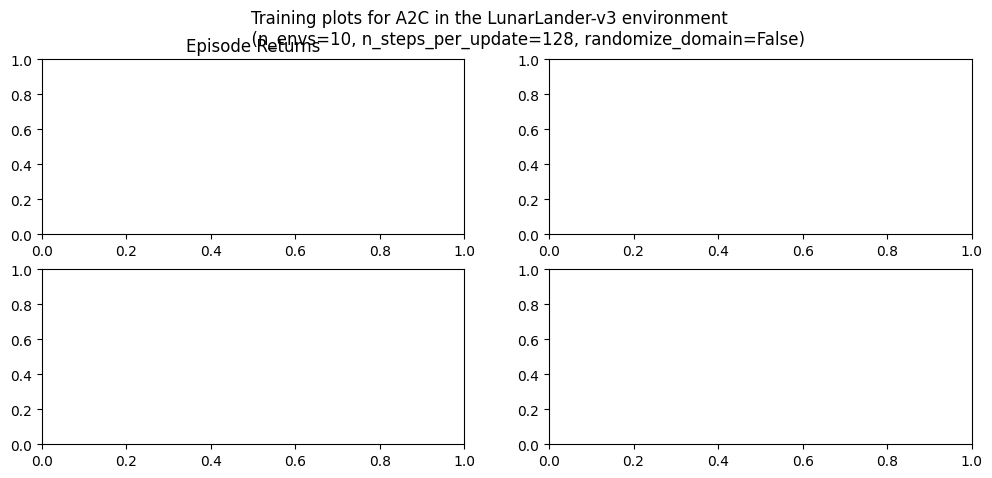

In [6]:
""" plot the results """

# %matplotlib inline

rolling_length = 20
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
fig.suptitle(
    f"Training plots for {agent.__class__.__name__} in the LunarLander-v3 environment \n \
             (n_envs={n_envs}, n_steps_per_update={n_steps_per_update}, randomize_domain={randomize_domain})"
)

# episode return
axs[0][0].set_title("Episode Returns")
episode_returns_moving_average = (
    np.convolve(
        np.array(envs_wrapper.return_queue).flatten(),
        np.ones(rolling_length),
        mode="valid",
    )
    / rolling_length
)
axs[0][0].plot(
    np.arange(len(episode_returns_moving_average)) / n_envs,
    episode_returns_moving_average,
)
axs[0][0].set_xlabel("Number of episodes")

# entropy
axs[1][0].set_title("Entropy")
entropy_moving_average = (
    np.convolve(np.array(entropies), np.ones(rolling_length), mode="valid")
    / rolling_length
)
axs[1][0].plot(entropy_moving_average)
axs[1][0].set_xlabel("Number of updates")


# critic loss
axs[0][1].set_title("Critic Loss")
critic_losses_moving_average = (
    np.convolve(
        np.array(crit_losses).flatten(), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[0][1].plot(critic_losses_moving_average)
axs[0][1].set_xlabel("Number of updates")


# actor loss
axs[1][1].set_title("Actor Loss")
actor_losses_moving_average = (
    np.convolve(np.array(actor_losses).flatten(), np.ones(rolling_length), mode="valid")
    / rolling_length
)
axs[1][1].plot(actor_losses_moving_average)
axs[1][1].set_xlabel("Number of updates")

plt.tight_layout()
plt.show()

In [ ]:
""" play a couple of showcase episodes """

n_showcase_episodes = 3

for episode in range(n_showcase_episodes):
    print(f"starting episode {episode}...")

    # create a new sample environment to get new random parameters
    if randomize_domain:
        env = gym.make(
            "LunarLander-v3",
            render_mode="human",
            gravity=-1,
            enable_wind=True,
            wind_power=19,
            turbulence_power=np.clip(
                np.random.normal(loc=1.5, scale=1.0), a_min=0.01, a_max=1.99
            ),
            max_episode_steps=500,
        )
    else:
        env = gym.make("LunarLander-v3", render_mode="human", max_episode_steps=500)

    # get an initial state
    state, info = env.reset()

    # play one episode
    done = False
    while not done:
        # select an action A_{t} using S_{t} as input for the agent
        with torch.no_grad():
            action, _, _, _ = agent.get_action(state[None, :])

        # perform the action A_{t} in the environment to get S_{t+1} and R_{t+1}
        state, reward, terminated, truncated, info = env.step(action.item())

        # update if the environment is done
        done = terminated or truncated

env.close()

starting episode 0...
starting episode 1...
starting episode 2...
